In [25]:
import warnings
warnings.filterwarnings("ignore")

In [26]:
# 1. IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [27]:
# 2. LOAD DATA

df = pd.read_csv("advanced_metallurgy_dataset.csv")

In [28]:
# 3. SELECT FEATURES (no output variables)

X = df[[
    "C","Cr","Ni","Mn",
    "Austenite_Temp","Temper_Temp",
    "Holding_Time","Cooling_Rate",
    "Ferrite","Pearlite","Martensite",
    "Grain_Size"
]]

In [29]:
# 4. SCALE DATA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

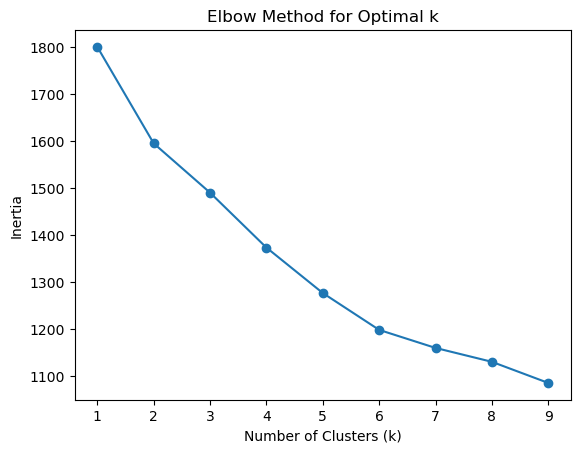

In [30]:
# 4.5 ELBOW METHOD (Find best k)

inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(X_scaled)
    inertia.append(kmeans_test.inertia_)

# Plot Elbow Graph
import matplotlib.pyplot as plt

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [31]:
# 5. APPLY K-MEANS

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [32]:
# APPLY PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [33]:
# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

In [34]:
# Add cluster labels
pca_df["Cluster"] = df["Cluster"]

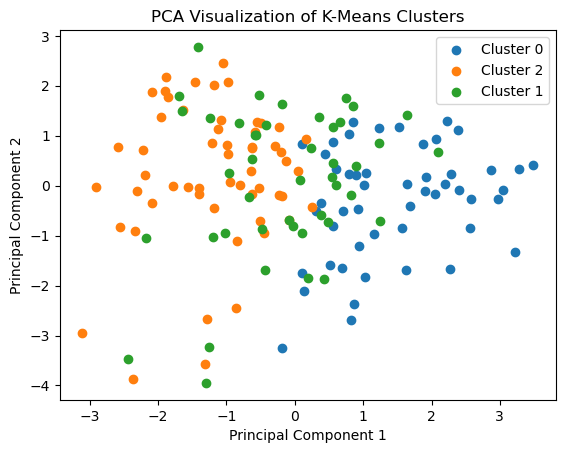

In [35]:
# 7. VISUALIZATION (CLUSTERS)

plt.figure()

for i in pca_df["Cluster"].unique():
    subset = pca_df[pca_df["Cluster"] == i]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {i}")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of K-Means Clusters")
plt.legend()
plt.show()

In [36]:
# 8. EXPLAINED VARIANCE

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.17340201 0.14976869]
Total Variance Explained: 0.3231707076767426


In [37]:
# 6. BASIC OUTPUT (CLEAN)

print("Cluster counts:")
print(df["Cluster"].value_counts())

Cluster counts:
Cluster
2    56
0    50
1    44
Name: count, dtype: int64


In [38]:
# 7. CLUSTER-WISE INSIGHTS

cluster_summary = df.groupby("Cluster").mean()
print("\nCluster Summary:\n", cluster_summary)



Cluster Summary:
                 C        Cr        Ni        Mn  Austenite_Temp  Temper_Temp  \
Cluster                                                                        
0        0.483800  1.135800  0.721000  0.876600      836.660000   438.780000   
1        0.524318  0.905000  0.979091  1.481136      825.840909   493.045455   
2        0.564821  1.175536  0.648036  0.841250      845.910714   434.250000   

         Holding_Time  Cooling_Rate   Ferrite  Pearlite  Martensite  \
Cluster                                                               
0           67.940000     27.100000  0.253638  0.199221    0.547141   
1           64.295455     23.204545  0.301122  0.371621    0.327257   
2           56.017857     23.053571  0.478506  0.330862    0.190632   

         Grain_Size    Hardness          UTS  Yield_Strength  
Cluster                                                       
0          4.363400  422.660000  1246.320000      871.920000  
1          5.727727  326.772727  10

In [39]:
# 8. MICROSTRUCTURE ANALYSIS

print("\nPhase Distribution:")
print(df.groupby("Cluster")[["Ferrite","Pearlite","Martensite"]].mean())


Phase Distribution:
          Ferrite  Pearlite  Martensite
Cluster                                
0        0.253638  0.199221    0.547141
1        0.301122  0.371621    0.327257
2        0.478506  0.330862    0.190632


In [40]:
# 9. MECHANICAL PROPERTIES ANALYSIS

print("\nMechanical Properties:")
print(df.groupby("Cluster")[["Hardness","UTS","Yield_Strength"]].mean())


Mechanical Properties:
           Hardness          UTS  Yield_Strength
Cluster                                         
0        422.660000  1246.320000      871.920000
1        326.772727  1055.590909      738.477273
2        271.875000   945.375000      661.321429


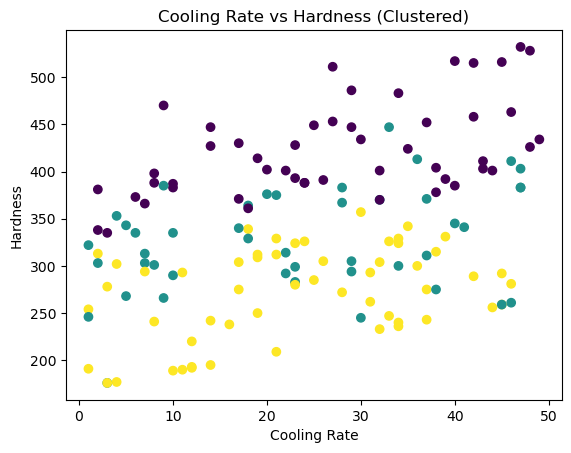

In [41]:
# 10. VISUALIZATION 1 (Cooling Rate vs Hardness)

plt.figure()
plt.scatter(df["Cooling_Rate"], df["Hardness"], c=df["Cluster"])
plt.xlabel("Cooling Rate")
plt.ylabel("Hardness")
plt.title("Cooling Rate vs Hardness (Clustered)")
plt.show()

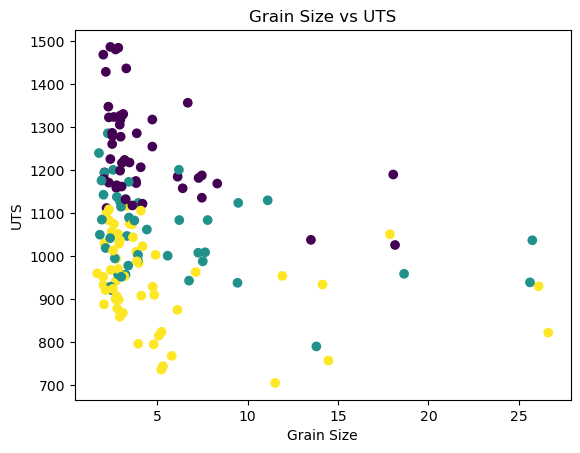

In [42]:
# 11. VISUALIZATION 2 (Grain Size vs UTS)

plt.figure()
plt.scatter(df["Grain_Size"], df["UTS"], c=df["Cluster"])
plt.xlabel("Grain Size")
plt.ylabel("UTS")
plt.title("Grain Size vs UTS")
plt.show()

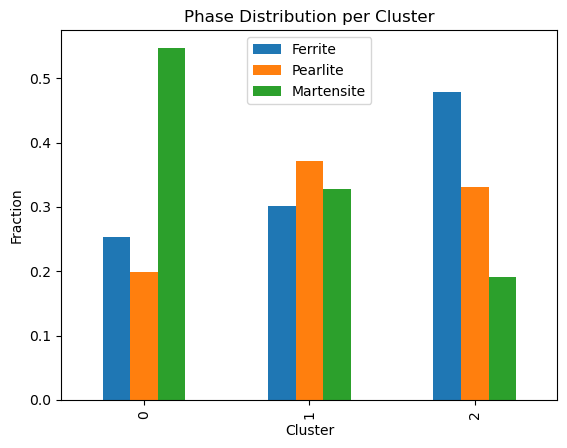

In [43]:
# 12. VISUALIZATION 3 (Phase Distribution)

df.groupby("Cluster")[["Ferrite","Pearlite","Martensite"]].mean().plot(kind="bar")
plt.title("Phase Distribution per Cluster")
plt.ylabel("Fraction")
plt.show()

In [44]:
# 13. INTERPRETATION PRINT (AUTO)

for i in range(3):
    print(f"\nCluster {i} Interpretation:")

    hardness = cluster_summary.loc[i, "Hardness"]
    martensite = cluster_summary.loc[i, "Martensite"]

    if martensite > 0.4:
        print("→ High martensite → High strength, brittle (quenched steel)")
    elif hardness < 250:
        print("→ Low hardness → Ductile ferrite-pearlite structure")
    else:
        print("→ Balanced properties → Tempered steel")


Cluster 0 Interpretation:
→ High martensite → High strength, brittle (quenched steel)

Cluster 1 Interpretation:
→ Balanced properties → Tempered steel

Cluster 2 Interpretation:
→ Balanced properties → Tempered steel
